In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("BostonHousing.csv")

In [17]:
df.head()

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [18]:
df.isnull().sum()

,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,5
Age,0
Distance,0
rad,0
tax,0


In [19]:
df['rm'].fillna(df['rm'].mean(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_2043/2300352499.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rm'].fillna(df['rm'].mean(), inplace=True)


,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,0
Age,0
Distance,0
rad,0
tax,0


In [20]:
x = df.drop('medv', axis=1)
y=df['medv']

In [21]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [22]:
!pip install tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(128, activation='relu'))      # One hidden layer (Dense(128) with ReLU activation).
model.add(Dense(1, activation='linear'))      # One output layer with a linear activation (for regression).

# Compiles the model
model.compile(loss='mae', optimizer='adam', metrics=['mse', 'mae'])

In [23]:
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 22.1972 - mae: 22.1972 - mse: 584.4799
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.5466 - mae: 21.5466 - mse: 556.8362 
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 20.8081 - mae: 20.8081 - mse: 526.7460  
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.8785 - mae: 19.8785 - mse: 490.8638 
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.7316 - mae: 18.7316 - mse: 448.1756 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17.3729 - mae: 17.3729 - mse: 400.8172 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 15.8509 - mae: 15.8509 - mse: 350.3755 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.3326 - mae: 14.3326 - mse: 300.2115 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.8480 - mae: 12.8480 - mse: 254.9908 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.5687 - mae: 11.5687 - mse: 216.2905 
Epoch 11/50
12/12 ━

In [24]:
metrics = model.evaluate(x_test, y_test)
metrics

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.9032 - mae: 3.9032 - mse: 34.9733 


[3.9032351970672607, 34.97332000732422, 3.9032351970672607]

In [25]:
y_pred = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [26]:
y_test = np.array(y_test).reshape(-1, 1)

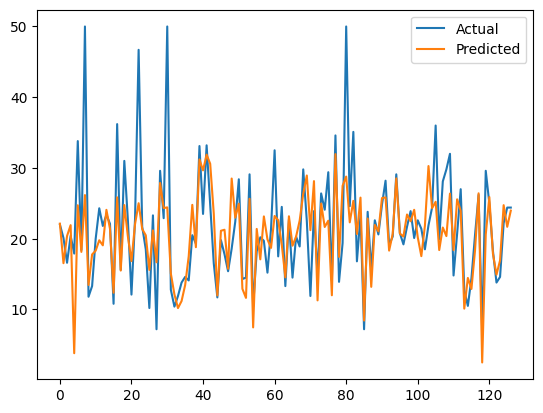

In [27]:
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()